In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

warnings.filterwarnings('ignore')

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

# Configuración visual
plt.style.use('default')
sns.set_palette("husl")

In [53]:
# Agregar carpeta src al path
sys.path.insert(0, r'C:\\Users\\Arturo\\Desktop\\Prueba1\\src')

# Importar funciones del proyecto
from prueba.data_preprocessing import (
    cargar_datos_crudos,
    crear_features_empleado,
    preparar_datos_para_ml
)

from prueba.model_training import (
    entrenar_modelos_regresion,
    obtener_predicciones
)

# Configuración general
seed = 42
project_root = r'C:\\Users\\Arturo\\Desktop\\Prueba1'

In [54]:
print("Cargando datos...")

datos_crudos = cargar_datos_crudos(
    os.path.join(project_root, 'data/01_raw/')
)

print("Creando features...")

df_features = crear_features_empleado(datos_crudos)

print("Preparando datos para Machine Learning...")

datos_ml = preparar_datos_para_ml(
    df_features,
    test_size=0.2,
    random_state=seed
)

X_train = datos_ml['X_train']
X_test = datos_ml['X_test']
y_train = datos_ml['y_train']
y_test = datos_ml['y_test']

feature_names = datos_ml['feature_names']

print("Datos preparados correctamente")

Cargando datos...
  Cargado: ausencias (360 filas, 7 columnas)
  Cargado: capacitaciones (412 filas, 8 columnas)
  Cargado: empleados (309 filas, 9 columnas)
  Cargado: evaluaciones (515 filas, 7 columnas)
Creando features...
Preparando datos para Machine Learning...
Datos preparados correctamente


In [39]:
print("Entrenando modelos...")

modelos = entrenar_modelos_regresion(
    X_train,
    y_train,
    random_state=seed
)

print("Modelos entrenados:")
print(list(modelos.keys()))

Entrenando modelos...
Modelos entrenados:
['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting', 'SVR', 'KNN']


In [40]:
predicciones = obtener_predicciones(
    modelos,
    X_test
)

In [41]:
resultados = []

for nombre, modelo in modelos.items():

    y_pred = predicciones[nombre]

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=5,
        scoring='r2'
    )

    resultados.append({
        'Modelo': nombre,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'CV Mean R2': cv_scores.mean()
    })

    print(f"\\nModelo: {nombre}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"CV Mean R²: {cv_scores.mean():.4f}")

\nModelo: Linear Regression
MAE: 8.0502
RMSE: 10.6019
R²: -12.5639
CV Mean R²: -4.6485
\nModelo: Ridge
MAE: 7.9150
RMSE: 10.3818
R²: -12.0066
CV Mean R²: -4.5942
\nModelo: Lasso
MAE: 7.6090
RMSE: 9.9385
R²: -10.9196
CV Mean R²: -4.5260
\nModelo: Random Forest
MAE: 6.4216
RMSE: 20.8634
R²: -51.5273
CV Mean R²: -1.3848
\nModelo: Gradient Boosting
MAE: 6.7201
RMSE: 34.4814
R²: -142.4787
CV Mean R²: -3.8713
\nModelo: SVR
MAE: 2.7974
RMSE: 4.3138
R²: -1.2456
CV Mean R²: -0.0628
\nModelo: KNN
MAE: 4.3042
RMSE: 17.1277
R²: -34.4009
CV Mean R²: -2.3092


In [42]:
resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    by='R2',
    ascending=False
)

resultados_df

,Modelo,MAE,RMSE,R2,CV Mean R2
5,SVR,2.797402,4.313774,-1.245595,-0.062770
2,Lasso,7.608988,9.938531,-10.919583,-4.525996
1,Ridge,7.915005,10.381813,-12.006578,-4.594205
0,Linear Regression,8.050158,10.601913,-12.563918,-4.648490
6,KNN,4.304194,17.127695,-34.400918,-2.309198
3,Random Forest,6.421550,20.863352,-51.527273,-1.384787
4,Gradient Boosting,6.720115,34.481433,-142.478653,-3.871289


In [43]:
ruta_metricas = os.path.join(
    project_root,
    'results/metrics/03_resumen_modelos.csv'
)

resultados_df.to_csv(
    ruta_metricas,
    index=False
)

print("Métricas guardadas correctamente")

Métricas guardadas correctamente


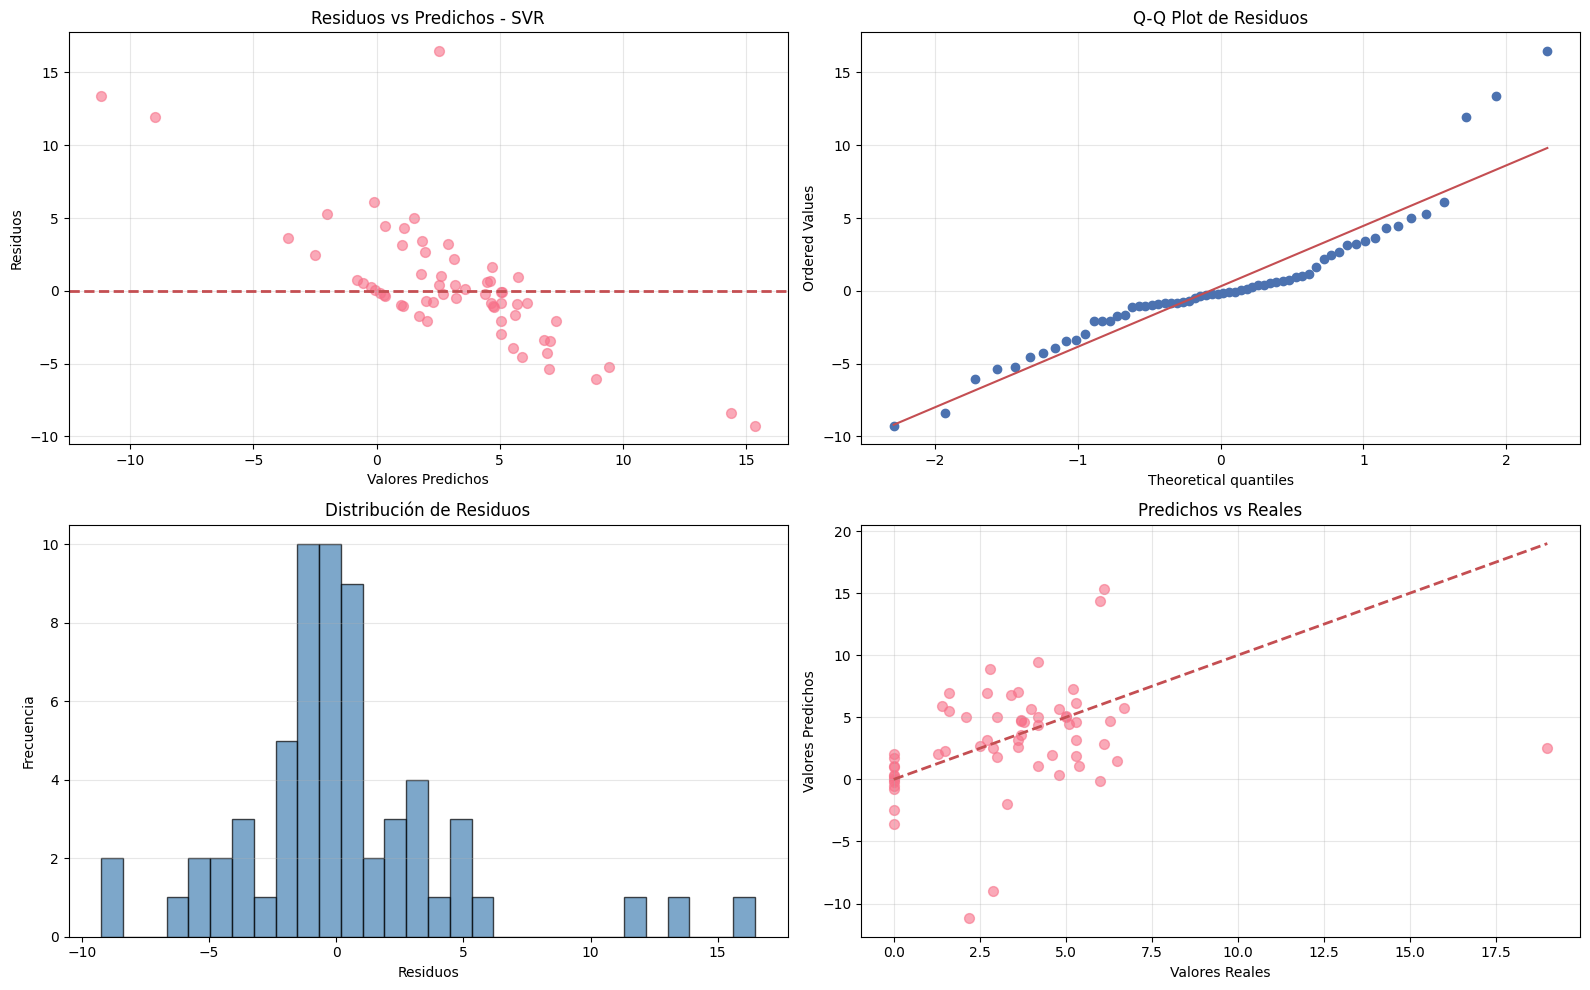

Mejor Modelo: SVR
Residuos - Media: 0.3055, Std: 4.3029


In [45]:
# Obtener mejor modelo
mejor_modelo_nombre = resultados_df.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_modelo_nombre]
y_pred_mejor = predicciones[mejor_modelo_nombre]

# Calcular residuos
residuos = y_test.values - y_pred_mejor

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residuos vs predichos
axes[0, 0].scatter(y_pred_mejor, residuos, alpha=0.6, s=50)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Valores Predichos')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title(f'Residuos vs Predichos - {mejor_modelo_nombre}')
axes[0, 0].grid(alpha=0.3)

# 2. Q-Q Plot (distribución normal de residuos)
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot de Residuos')
axes[0, 1].grid(alpha=0.3)

# 3. Distribución de residuos
axes[1, 0].hist(residuos, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Predichos vs Reales
axes[1, 1].scatter(y_test, y_pred_mejor, alpha=0.6, s=50)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Valores Reales')
axes[1, 1].set_ylabel('Valores Predichos')
axes[1, 1].set_title('Predichos vs Reales')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/07_analisis_residuos.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mejor Modelo: {mejor_modelo_nombre}")
print(f"Residuos - Media: {residuos.mean():.4f}, Std: {residuos.std():.4f}")

In [50]:
# Crear reporte en texto\nreporte_path = os.path.join(project_root, 'results/reports/03_evaluacion_modelos.txt')\nos.makedirs(os.path.dirname(reporte_path), exist_ok=True)\n\nwith open(reporte_path, 'w', encoding='utf-8') as f:\n    f.write(\"=\"*80 + \"\\n\")\n    f.write(\"REPORTE DE EVALUACIÓN DE MODELOS DE REGRESIÓN\\n\")\n    f.write(\"=\"*80 + \"\\n\\n\")\n    \n    f.write(\"1. RESUMEN DE DESEMPEÑO\\n\")\n    f.write(\"-\"*80 + \"\\n\")\n    f.write(resultados_df.to_string())\n    \n    f.write(\"\\n\\n2. MEJOR MODELO\\n\")\n    f.write(\"-\"*80 + \"\\n\")\n    f.write(f\"Modelo seleccionado: {mejor_modelo_nombre}\\n\")\n    f.write(f\"R² en Test: {resultados_df.iloc[0]['R2']:.4f}\\n\")\n    f.write(f\"MAE: {resultados_df.iloc[0]['MAE']:.4f}\\n\")\n    f.write(f\"RMSE: {resultados_df.iloc[0]['RMSE']:.4f}\\n\")\n    \n    f.write(\"\\n3. ESTADÍSTICAS DE RESIDUOS\\n\")\n    f.write(\"-\"*80 + \"\\n\")\n    f.write(f\"Media residuos: {residuos.mean():.4f}\\n\")\n    f.write(f\"Desv. Est: {residuos.std():.4f}\\n\")\n    f.write(f\"Min: {residuos.min():.4f}\\n\")\n    f.write(f\"Max: {residuos.max():.4f}\\n\")\n\nprint(f\"Reporte guardado en: {reporte_path}\")\nprint(\"\\n✓ Evaluación completada exitosamente\")"

## Exportar Reporte Final

In [51]:
import pickle

print("="*80)
print("REPORTE FINAL - EVALUACIÓN DE MODELOS DE REGRESIÓN")
print("="*80)

print("\n1. RESUMEN DE DESEMPEÑO:")
print("-"*80)
for idx, row in resultados_df.iterrows():
    print(f"\n{idx+1}. {row['Modelo']}:")
    print(f"   MAE:        {row['MAE']:.4f}")
    print(f"   RMSE:       {row['RMSE']:.4f}")
    print(f"   R²:         {row['R2']:.4f}")
    print(f"   CV Mean R²: {row['CV Mean R2']:.4f}")

print("\n" + "="*80)
print("2. MEJOR MODELO SELECCIONADO:")
print("-"*80)
print(f"Nombre: {mejor_modelo_nombre}")
print(f"R² en Test: {resultados_df.iloc[0]['R2']:.4f}")
print(f"MAE en Test: {resultados_df.iloc[0]['MAE']:.4f}")
print(f"RMSE en Test: {resultados_df.iloc[0]['RMSE']:.4f}")
print(f"CV Mean R²: {resultados_df.iloc[0]['CV Mean R2']:.4f}")

# Análisis de sobreajuste
overfit_pct = ((r2_train[resultados_df.index[0]] - resultados_df.iloc[0]['R2']) / r2_train[resultados_df.index[0]] * 100) if r2_train[resultados_df.index[0]] != 0 else 0
print(f"Sobreajuste: {overfit_pct:.1f}%")

if overfit_pct < 10:
    print("✓ Modelo bien generalizado (bajo sobreajuste)")
elif overfit_pct < 20:
    print("✓ Modelo con sobreajuste moderado")
else:
    print("⚠ Modelo con sobreajuste significativo")

print("\n" + "="*80)
print("3. ESTADÍSTICAS DE RESIDUOS:")
print("-"*80)
print(f"Media: {residuos.mean():.4f} (ideal: cercano a 0)")
print(f"Desv. Est.: {residuos.std():.4f}")
print(f"Min: {residuos.min():.4f}")
print(f"Max: {residuos.max():.4f}")
print(f"Rango intercuartil: {np.percentile(residuos, 75) - np.percentile(residuos, 25):.4f}")

print("\n" + "="*80)
print("4. RECOMENDACIONES:")
print("-"*80)

if resultados_df.iloc[0]['R2'] > 0.8:
    print("✓ Modelo con excelente ajuste. Listo para predicciones.")
elif resultados_df.iloc[0]['R2'] > 0.6:
    print("✓ Modelo con buen ajuste. Puede usarse con cautela.")
elif resultados_df.iloc[0]['R2'] > 0.4:
    print("⚠ Modelo con ajuste moderado. Considerar optimización.")
else:
    print("✗ Modelo con pobre ajuste. Se recomienda:")
    print("  - Recopilar más datos")
    print("  - Ingeniería de features")
    print("  - Optimización de hiperparámetros")

print("\n" + "="*80)

# Guardar mejor modelo
ruta_modelo = os.path.join(project_root, 'results/models/best_model.pkl')
os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)

with open(ruta_modelo, 'wb') as f:
    pickle.dump(mejor_modelo, f)

print(f"Mejor modelo guardado en: {ruta_modelo}")

REPORTE FINAL - EVALUACIÓN DE MODELOS DE REGRESIÓN

1. RESUMEN DE DESEMPEÑO:
--------------------------------------------------------------------------------

6. SVR:
   MAE:        2.7974
   RMSE:       4.3138
   R²:         -1.2456
   CV Mean R²: -0.0628

3. Lasso:
   MAE:        7.6090
   RMSE:       9.9385
   R²:         -10.9196
   CV Mean R²: -4.5260

2. Ridge:
   MAE:        7.9150
   RMSE:       10.3818
   R²:         -12.0066
   CV Mean R²: -4.5942

1. Linear Regression:
   MAE:        8.0502
   RMSE:       10.6019
   R²:         -12.5639
   CV Mean R²: -4.6485

7. KNN:
   MAE:        4.3042
   RMSE:       17.1277
   R²:         -34.4009
   CV Mean R²: -2.3092

4. Random Forest:
   MAE:        6.4216
   RMSE:       20.8634
   R²:         -51.5273
   CV Mean R²: -1.3848

5. Gradient Boosting:
   MAE:        6.7201
   RMSE:       34.4814
   R²:         -142.4787
   CV Mean R²: -3.8713

2. MEJOR MODELO SELECCIONADO:
----------------------------------------------------------------

## Reporte Final y Recomendaciones

## Análisis de Residuos del Mejor Modelo

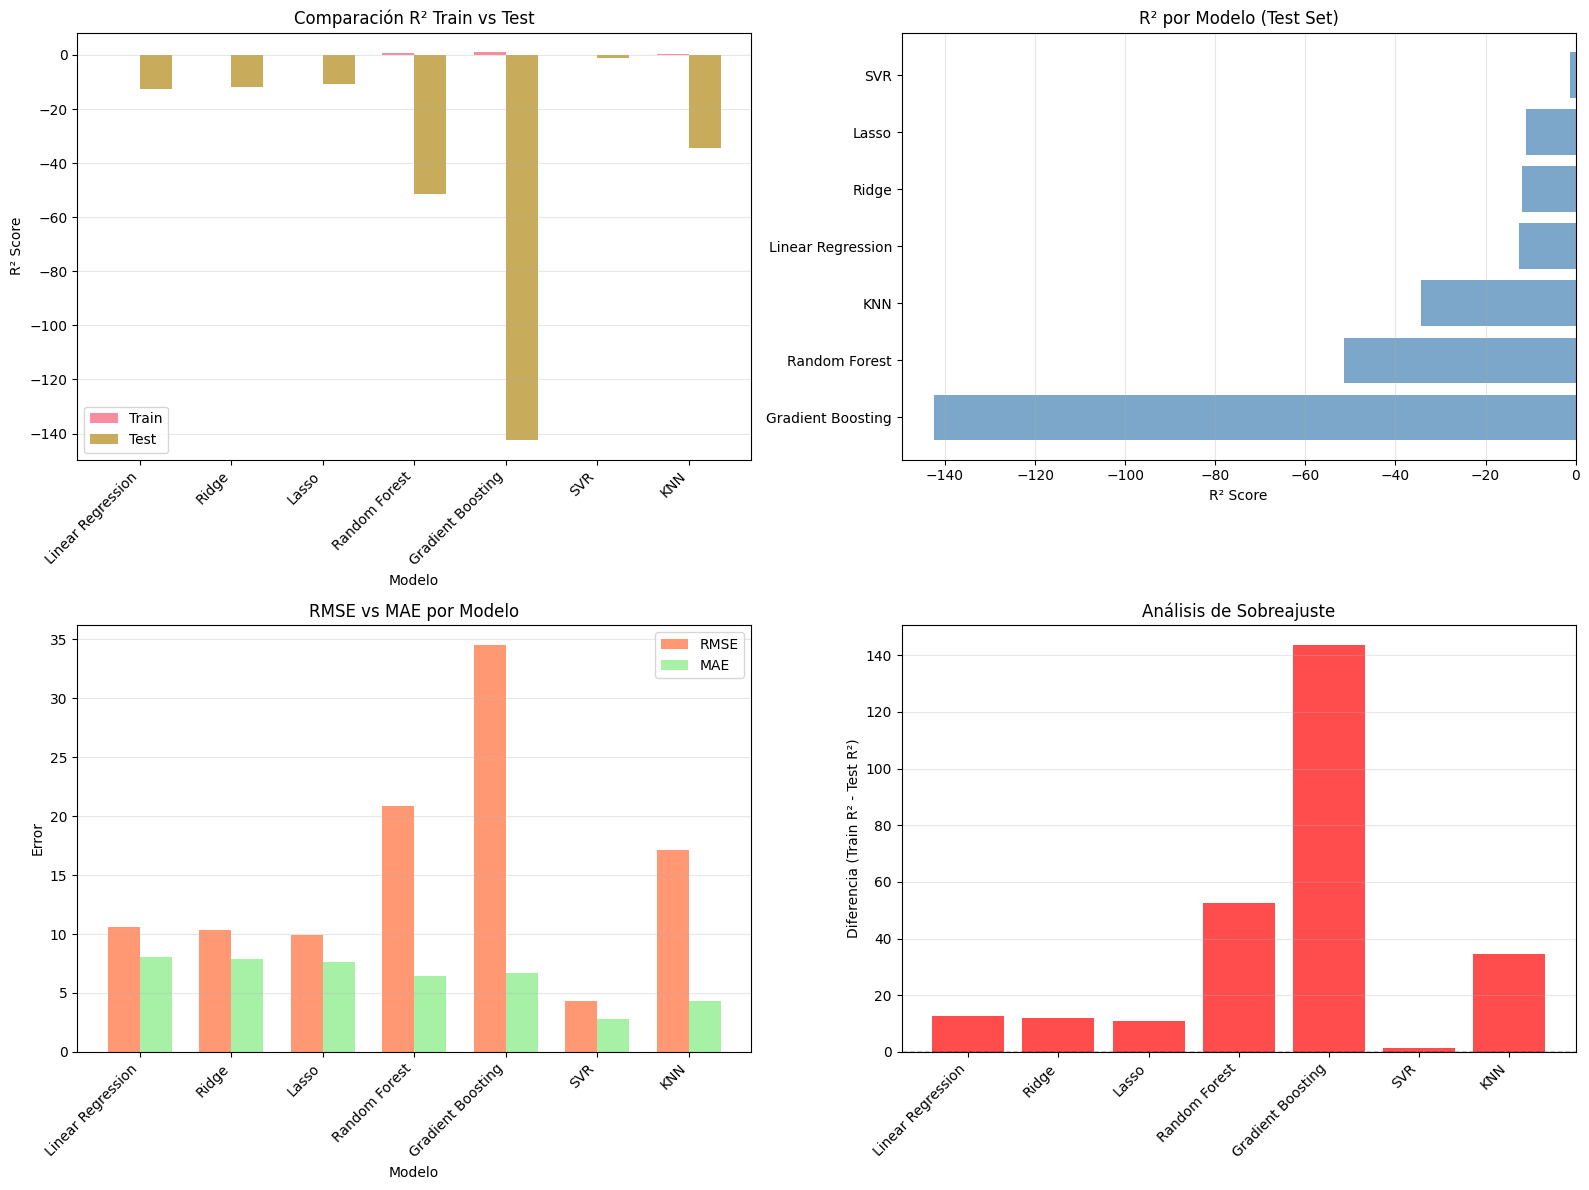

Gráfico de evaluación guardado


In [52]:
# Gráfico de comparación de R² entre modelos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparación R² Train vs Test
modelos_nombres = list(modelos.keys())
r2_train = []
r2_test = []

for nombre, modelo in modelos.items():
    r2_train.append(modelo.score(X_train, y_train))
    r2_test.append(modelo.score(X_test, y_test))

x_pos = np.arange(len(modelos_nombres))
width = 0.35

axes[0, 0].bar(x_pos - width/2, r2_train, width, label='Train', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, r2_test, width, label='Test', alpha=0.8)
axes[0, 0].set_xlabel('Modelo')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Comparación R² Train vs Test')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(modelos_nombres, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')

# 2. Comparación de métricas por modelo
resultados_df_sorted = resultados_df.sort_values('R2', ascending=True)
axes[0, 1].barh(resultados_df_sorted['Modelo'], resultados_df_sorted['R2'], color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('R² Score')
axes[0, 1].set_title('R² por Modelo (Test Set)')
axes[0, 1].grid(alpha=0.3, axis='x')

# 3. RMSE por modelo
rmse_values = []
mae_values = []

for nombre, modelo in modelos.items():
    y_pred = predicciones[nombre]
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    rmse_values.append(rmse)
    mae_values.append(mae)

x_pos_rmse = np.arange(len(modelos_nombres))
axes[1, 0].bar(x_pos_rmse - width/2, rmse_values, width, label='RMSE', alpha=0.8, color='coral')
axes[1, 0].bar(x_pos_rmse + width/2, mae_values, width, label='MAE', alpha=0.8, color='lightgreen')
axes[1, 0].set_xlabel('Modelo')
axes[1, 0].set_ylabel('Error')
axes[1, 0].set_title('RMSE vs MAE por Modelo')
axes[1, 0].set_xticks(x_pos_rmse)
axes[1, 0].set_xticklabels(modelos_nombres, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Sobreajuste (diferencia R² train - test)
overfit = [r2_train[i] - r2_test[i] for i in range(len(modelos_nombres))]
colors_overfit = ['red' if x > 0.1 else 'green' for x in overfit]

axes[1, 1].bar(modelos_nombres, overfit, color=colors_overfit, alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_ylabel('Diferencia (Train R² - Test R²)')
axes[1, 1].set_title('Análisis de Sobreajuste')
axes[1, 1].set_xticklabels(modelos_nombres, rotation=45, ha='right')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/06_evaluacion_modelos.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico de evaluación guardado")

## Visualizaciones de Evaluación